In [31]:
import os

import tifffile
import numpy as np
import cv2
%matplotlib inline
from matplotlib import pyplot as plt
from math import sqrt, ceil, hypot, degrees, atan

from scipy.ndimage.morphology import binary_fill_holes
from scipy import interpolate
from skimage import feature
from skimage.filters import threshold_otsu, gaussian
from skimage.transform import rotate, SimilarityTransform
from skimage.morphology import disk, erosion, remove_small_holes, binary_opening, remove_small_objects

In [2]:
filepath='/Users/christina.bukas/Documents/AI_projects/datasets/NMOs/Contraction_videos/dev'
files = [file for file in os.listdir(filepath) if file.endswith('.tif')]
print('Dataset includes ', len(files), ' videos')

Dataset includes  15  videos


### All videos have the same size in pixels but varying lengths

In [4]:
for file in files:
    img=tifffile.imread(os.path.join(filepath, file))
    print('File: ', file, 'Shape: ', img.shape)

File:  220516_No contraction videos.lif - O1445_2a.tif Shape:  (1208, 256, 256)
File:  Weak contraction.lif - O1318_3a.tif Shape:  (796, 256, 256)
File:  220516_No contraction videos.lif - O1450_2 curare II.tif Shape:  (1208, 256, 256)
File:  Strong contraction.lif - O1319_1a.tif Shape:  (1813, 256, 256)
File:  Weak contraction.lif - O1318_2a.tif Shape:  (1813, 256, 256)
File:  Strong contraction.lif - O1464_1a.tif Shape:  (1208, 256, 256)
File:  Strong contraction.lif - O1468_1b.tif Shape:  (1208, 256, 256)
File:  Strong contraction.lif - O1466_2a.tif Shape:  (1208, 256, 256)
File:  Weak contraction.lif - O1443_1b.tif Shape:  (1509, 256, 256)
File:  220516_No contraction videos.lif - O1319_3a.tif Shape:  (1813, 256, 256)
File:  Strong contraction.lif - O1464_2a.tif Shape:  (1208, 256, 256)
File:  Weak contraction.lif - O1318_1b.tif Shape:  (1813, 256, 256)
File:  Weak contraction.lif - O1301_3a.tif Shape:  (1813, 256, 256)
File:  220516_No contraction videos.lif - O1498_1a curare.tif 

# Useful functions for border extraction

In [46]:
def remove_border_points(border_points):
    '''Remove the white pixels on border of image'''
    border_x = list(border_points[0])
    border_y = list(border_points[1])
    i = 0
    remove_ids = []
    for x, y in zip(border_x, border_y):
        if x<10 or x>245 or y<10 or y>245: remove_ids.append(i)
        i+=1
    for i in reversed(remove_ids):
        border_x.pop(i)
        border_y.pop(i)
    return (np.array(border_x), np.array(border_y))

def extract_border(img_slice, sigma_smooth=2, sigma_edge=3):
    '''
    Extract the border from a single frame, by following:
    1. Threshold image using Otsu thresholding
    2. Apply morphological opening and fill any holes in the binary image
    3. Compute edges using the Canny edge Detection algorithm
    4. Remove white pixels from border of image
    6. Return border coordinates and binary image
    '''
    img_smooth = gaussian(img_slice, sigma_smooth)
    thresh = threshold_otsu(img_smooth)
    image_thresh = img_smooth > thresh
    image_thresh = binary_opening(image_thresh, disk(4))
    image_thresh = remove_small_objects(image_thresh, min_size=400)
    
    edges = feature.canny(image_thresh, sigma_edge)
    x,y = remove_border_points((np.where(edges)))

    return (x,y), image_thresh 

def sort_border(x,y):
    ''' Sort border pixels such that the signal coordinates are continuous'''
    sorted_x = x[np.argsort(x)]
    sorted_y = y[np.argsort(y)]
    max_dist_x = sorted_x[-1] - sorted_x[0]
    max_dist_y = sorted_y[-1] - sorted_y[0]
    if max_dist_x > max_dist_y: point0 = np.where(x==sorted_x[0])[0][0]
    else: point0 = np.where(y==sorted_y[0])[0][0]
    sorted_ids = np.argsort((x-x[point0])**2+(y-y[point0])**2) # x+y
    x = x[sorted_ids]
    y = y[sorted_ids]
    return (x,y)

def get_normals(border_points, track_points, length, img_size):
    ''' Get the normals of the points we wish to track on border'''
    border_points = np.asarray(border_points).T
    track_points = np.asarray(track_points).T
    static_points_x = []
    static_points_y = []
    for point in track_points: 
        idx=np.where(np.all(point==border_points, axis=1))[0][0]
        if idx==border_points.shape[0]-1:
            x0, y0, xa, ya = point[0], point[1], border_points[idx-1, 0], border_points[idx-1, 1] 
            dx, dy = x0-xa, y0-ya
        else:
            x0, y0, xa, ya = point[0], point[1], border_points[idx+1, 0], border_points[idx+1, 1]
            dx, dy = xa-x0, ya-y0
        norm = hypot(dx, dy) * 1/length
        dx /= norm
        dy /= norm
        dx0 = max(0, min(x0-dy, img_size))
        dy0 = max(0, min(y0+dx, img_size))
        #plt.plot((x0, dx0), (y0, dy0))    # plot the normals
        static_points_x.append(dx0)
        static_points_y.append(dy0)
    return (static_points_x, static_points_y)   

def compute_static_on_img_border(image_bin):
    ''' Get a point on the border of the image which is mostly organoid'''
    # get row or col on border of image
    image_top = 1 - image_bin[0,:]
    image_bottom = 1 - image_bin[-1,:]
    image_left = 1 - image_bin[:,0]
    image_right = 1 - image_bin[:,-1]
    
    # find num of pixels on these rows, columns
    image_top_sum = np.sum(image_top)
    image_bottom_sum = np.sum(image_bottom)
    image_left_sum = np.sum(image_left)
    image_right_sum = np.sum(image_right)
    images_border_sums = [image_top_sum, image_bottom_sum, image_left_sum, image_right_sum]
    larger_border_id = images_border_sums.index(max(images_border_sums))
    
    # and define static point in middle of border row or col with most black(i.e. organoid) pixels
    if larger_border_id==0:
        static_point = (0,128)
    elif larger_border_id==1:
        static_point = (256,128)
    elif larger_border_id==2:
        static_point = (128,0)
    else:
        static_point = (128,256)
    return np.array(static_point)len(static_points.shape)==1

def line_function(x, ys, ye, xs, xe):
    ''' Find y for a given x when we know start and end point of line '''
    return round(x*(ys-ye)/(xs-xe)+(ye*xs-xe*ys)/(xs-xe))

def line_approx(img, min_point, max_point, length=30):
    '''NEED TO CONFIRM THIS WORKS CORRECTLY!!!'''
    x1,y1 = min_point
    x2,y2 = max_point 
    xs = min(x1,x2)
    xe = max(x1,x2)
    ys = min(y1,y2)
    ye = max(y1,y2)
    
    xm = max((x2-x1)//2, (x1-x2)//2)
    ym = max((y2-y1)//2, (y1-y2)//2)
    img_l = img[:xm,:ym]
    img_r = img[xm:,ym:]
    if np.mean(img_l)> np.mean(img_r):
        # the organoid is on the left of the border
        sign = -1
    else: sign = 1
    length = sign*length
    for x in range(xm-10,xm+10):
        x0, y0, xa, ya = xm, ym, xm+1,line_function(xm+1, ys, ye, xs, xe)
        dx, dy = x0-xa, y0-ya
        norm = hypot(dx, dy) * 1/length
        dx /= norm
        dy /= norm
        dx0 = max(0, min(x0-dy, 255))
        dy0 = max(0, min(y0+dx, 255))
        return (dx0,dy0)
    
def get_tracking_points(frame0, num_track_points=10, num_static_points=1, method='img-border', static_distance=-30):
    '''Given a frame return the points on norder to be tracked along with statis point(s) from which the distance need be computed'''
    
    #get the organoid border and remove image border pixels
    (x,y), image_bin = extract_border(frame0)    
    # sort the signal so that array of coordinates is continuous
    border_points = sort_border(x, y)
    
    # get points on border of organoid to track
    num_border_points = border_points[0].shape[0]
    idx = np.round(np.linspace(0, num_border_points - 1, num_track_points)).astype(int)
    track_points = (border_points[0][idx], border_points[1][idx])
    
    # get one or multiple static points depending on num_static_points var.
    if num_static_points==1 and method=='line-approx':
        static_points = line_approx(frame0, (x[-1],y[-1]), (x[0], y[0]))
    elif num_static_points==1 and method=='img-border':
        static_points = compute_static_on_img_border(image_bin)
    else:
        static_points = get_normals(border_points, track_points, length=static_distance, img_size=frame0.shape[1])
    
    return border_points, track_points, static_points

def get_border_angle(x , y):
    ''' Compute the angle of the border considering it as a line from first to last point'''
    xl = x[-1] - x[0]
    yl = y[-1] - y[0]
    theta = degrees(atan(xl/yl))
    return theta


# Useful functions for tracking points in video

In [82]:
def convert_vid2rgb(vid):
    '''Convert grayscale video to RGB'''
    vid_color = np.zeros((vid.shape[0], vid.shape[1], vid.shape[2], 3))
    for i in range(vid.shape[0]):
        frame = vid[i,:,:]
        vid_color[i] = cv2.cvtColor(frame, cv2.COLOR_GRAY2RGB)
    return vid_color.astype(np.uint8)

# https://www.geeksforgeeks.org/python-opencv-optical-flow-with-lucas-kanade-method/
def track_points_in_vid(filename, vid, track_points, static_points, lose_points= True, view=False, wait=100, subsample=1, out=None):
        
    if view: 
        vid_color = convert_vid2rgb(vid) # convert video to rgb format
        cv2.destroyAllWindows()

    # Parameters for lucas kanade optical flow
    lk_params = dict( winSize = (35, 35), #(15, 15) (35, 35)
                      maxLevel = 2, #2,
                      criteria = (cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

    # Take first frame and convert points from tuples to arrays
    old_gray = vid[0].copy() 

    # if a single static point
    #if len(static_points.shape)==1: static_points = static_points[:, np.newaxis]
    #print(static_points.shape, 'aaaaaaaa')
        
    track_points = np.asarray(track_points).T
    track_points = track_points[:, np.newaxis, :].astype(np.float32) # shape is (10,1,2) for 10 points to track
    tracked_points_vid = np.zeros((track_points.shape[0], vid.shape[0])) # shape is e.g. [10, 1, 2, 1000]
    if len(static_points.shape)==1:
        tracked_points_vid[:, 0] = (track_points[:, 0, 0] - static_points[0])**2 + (track_points[:, 0, 1] - static_points[1])**2
    else:
        static_points = np.asarray(static_points).T
        static_points = static_points[:, np.newaxis, :].astype(np.float32)
        tracked_points_vid[:, 0] = (track_points[:, 0, 0] - static_points[:, 0, 0])**2 + (track_points[:, 0, 1] - static_points[:, 0, 1])**2

    final_tracked_points_vid = tracked_points_vid.copy()
    original_ids = np.arange(10)
    points_lost = 0

    for frame_id in range(1, vid.shape[0]//subsample):   
        
        if view: frame = vid_color[frame_id] 
        frame_gray = vid[frame_id] 

        if lose_points:
            # calculate optical flow
            tracked_points, st, err = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, track_points, None, **lk_params) #, flags = cv2.OPTFLOW_USE_INITIAL_FLOW)
            if tracked_points is not None:
                # Select good points
                good_ids, _ = np.where(st==1)
                bad_ids, _ = np.where(st==0)
                if len(bad_ids)!=0:
                    original_ids_final = original_ids[bad_ids]                
                    final_tracked_points_vid[original_ids_final, :] = tracked_points_vid[original_ids_final, :]
                    original_ids = np.delete(original_ids, bad_ids, 0)
                good_new_points = tracked_points[st == 1]
                if len(static_points.shape)==1:
                    tracked_points_vid[original_ids, frame_id] = (good_new_points[:,0] - static_points[0])**2 + (good_new_points[:,1] - static_points[1])**2
                else: 
                    static_points = static_points[st==1]
                    static_points = static_points[:, np.newaxis, :]
                    #tracked_points_vid[original_ids, frame_id, :] = good_new_points
                    tracked_points_vid[original_ids, frame_id] = (good_new_points[:,0] - static_points[:,0])**2 + (good_new_points[:,1] - static_points[:,1])**2
                track_points = good_new_points.reshape(-1, 1, 2)
                
        else:
            tracked_points1, _, _ = cv2.calcOpticalFlowPyrLK(old_gray, frame_gray, track_points, None, **lk_params) 
            tracked_points0, _, _ = cv2.calcOpticalFlowPyrLK(frame_gray, old_gray, tracked_points1, None, **lk_params)
            d = abs(track_points-tracked_points0).reshape(-1, 2).max(-1)
            good = d < 1 
            new_tracks = []

            for i, (tr, (x, y), good_flag) in enumerate(zip(track_points, tracked_points1.reshape(-1, 2), good)):
                if not good_flag: tr = (tr[0,0], tr[0,1])
                else: tr = (x, y)
                new_tracks.append(tr)
                if len(static_points.shape)==1:
                    final_tracked_points_vid[i, frame_id] = #FIX
                else: 
                    final_tracked_points_vid[i, frame_id] = #FIX
            track_points = np.array(new_tracks)
            track_points = track_points[:, np.newaxis, :]
                
        # draw the tracks
        for i, new_point in enumerate(track_points):
            if len(static_points.shape)==1: static_x, static_y = static_points.ravel()
            else: static_x, static_y = static_points[i].ravel()
            new_x, new_y = new_point.ravel()

            if view:
                frame = cv2.circle(frame, (new_y, new_x), 5, (0, 255, 0), -1) # add tracked point
                frame = cv2.circle(frame, (static_y, static_x), radius=5, color=(0, 255, 0), thickness=-1)
                frame = cv2.line(frame, (static_y, static_x), (new_y, new_x), (0, 0, 255), thickness=2)            

            # Updating previous frame and points 
            old_gray = frame_gray.copy()

            if out: out.write(frame)
        if view:
            cv2.namedWindow(filename) 
            cv2.moveWindow(filename, 200,200) 
            cv2.imshow(filename, frame)
            k = cv2.waitKey(wait)
            if k == 27:
                break
    
    if lose_points:   
        final_tracked_points_vid[original_ids, :] = tracked_points_vid[original_ids, :]
        points_lost = final_tracked_points_vid.shape[0] - original_ids.shape[0]
        
    return final_tracked_points_vid, points_lost, out


## Extract the organoid border from the first frame of all videos and visualize results

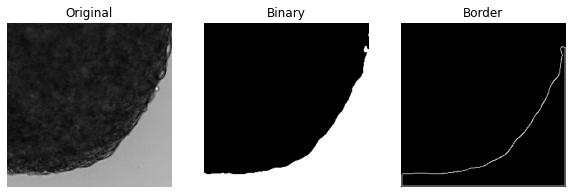

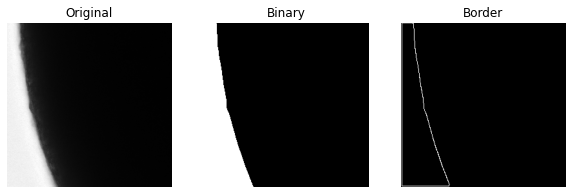

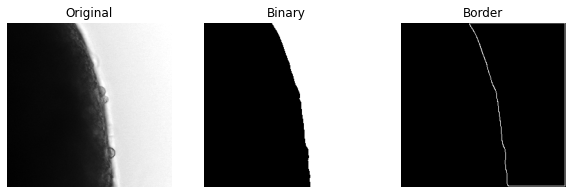

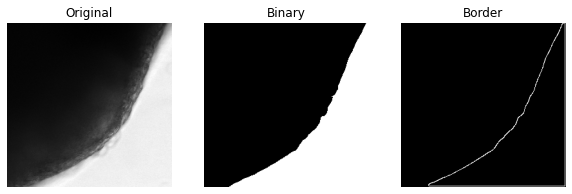

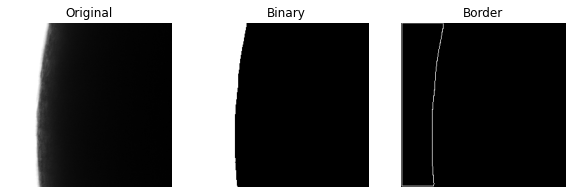

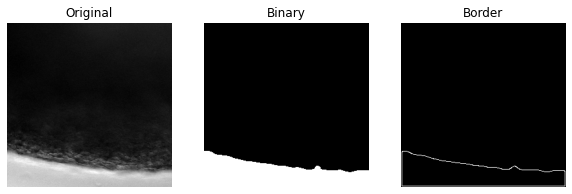

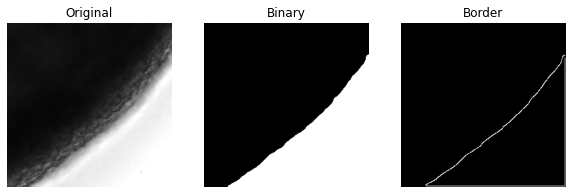

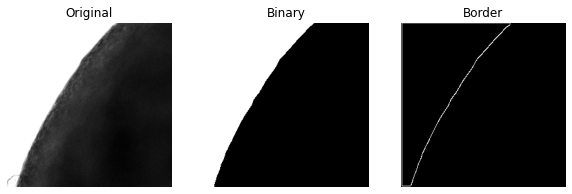

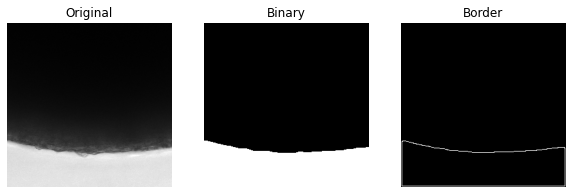

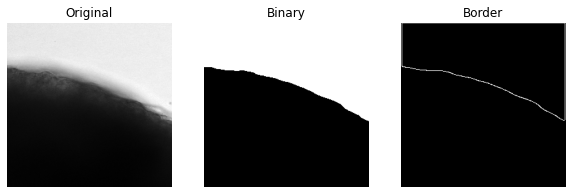

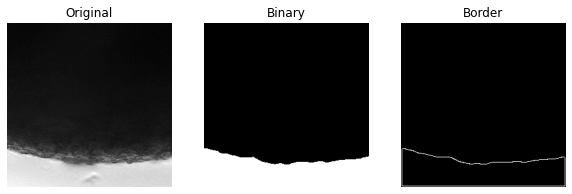

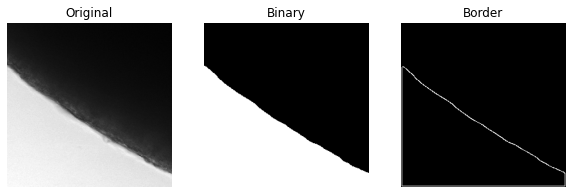

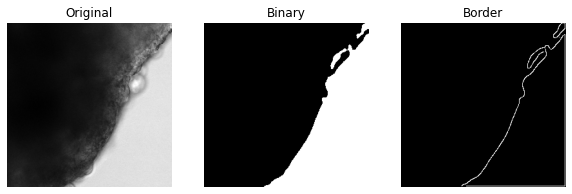

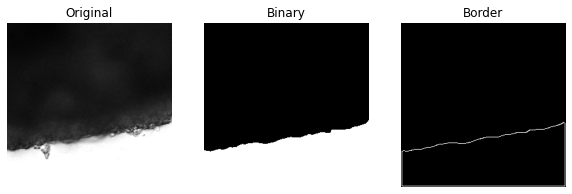

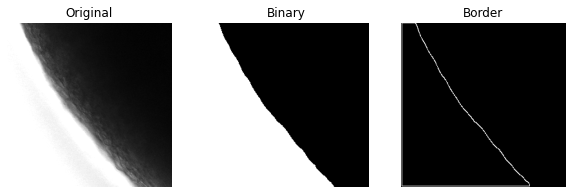

In [121]:
for file in files:
    slice_id = 0
    img = tifffile.imread(os.path.join(filepath, file))
    img_slice = img[slice_id,:,:]
    
    img_smooth = gaussian(img_slice, 2)
    thresh = threshold_otsu(img_smooth)
    image_thresh = img_smooth > thresh
    image_thresh = (1 - binary_fill_holes(1-image_thresh)).astype(bool)
    edges = feature.canny(image_thresh, 3)
    
    fig, ax = plt.subplots(1,3, figsize=(10,100))
    #fig.suptitle(file)
    ax[0].imshow(img_slice, cmap='gray')
    ax[0].title.set_text('Original')
    ax[0].axis('off')
    ax[1].imshow(image_thresh, cmap='gray')
    ax[1].title.set_text('Binary')
    ax[1].axis('off')
    ax[2].imshow(edges, cmap='gray')
    ax[2].title.set_text('Border')
    ax[2].axis('off')

## Display videos of border extraction at every frame

Uncomment end if you want to find out how many points are on border

In [39]:
# uncomment if you would reather save a video with output rather than visualise live
# out = cv2.VideoWriter('output.mp4',cv2.VideoWriter_fourcc('m', 'p', '4', 'v'), 100, (512,200))

# uncomment to find number of points on border
num_pixel_edges = []

subsample=20

for i in range(len(files)):
    print(files[i])
    cv2.destroyAllWindows()
    example_file = files[i]
    vid = tifffile.imread(os.path.join(filepath, example_file))
    frames=[]

    for frame_id in range(vid.shape[0]//subsample):   
        (x,y), _ = extract_border(vid[frame_id], sigma_smooth=2, sigma_edge=3)
        x, y = sort_border(x, y)
        #num_pixel_edges.append(x.shape[0]) # uncomment to find number of points on border
        
        # Rotate border so that is always parallel to x-axis
        theta = get_border_angle(x , y)
        mask = np.zeros(vid[frame_id].shape, dtype=bool)
        mask[(x,y)] = True #size 256, 256
        mask_r = rotate(mask, theta, resize=True) # shape usually 305,305
        
        # Pad so we alwyas have a fixed size image
        resize_size = (512 - mask_r.shape[0], 512 - mask_r.shape[1])
        mask_r = np.pad(mask_r, ((resize_size[0]//2+mask_r.shape[0]%2, resize_size[0]//2), (resize_size[1]//2+mask_r.shape[1]%2, resize_size[1]//2)))
    
        # Translate always relative to middle of image 
        if frame_id==0: mean_x = int(np.mean(np.where(mask_r)[0]))
        mask_r = mask_r[mean_x-100:mean_x+100,:]
        
        # Display
        frame = cv2.cvtColor((mask_r*255).astype(np.uint8),cv2.COLOR_GRAY2RGB)
        #out.write(frame) # uncomment for video saving
        cv2.namedWindow(files[i]) 
        cv2.moveWindow(files[i], 200,200) 
        cv2.imshow(files[i], (mask_r*255).astype(np.uint8))
        k = cv2.waitKey(1)
        if k == 27: break
            
# out.release() # uncomment for video saving

# uncomment to find number of points on border
# num_pixel_edges = np.array(num_pixel_edges)
# print('Average number of pixels on border: ', np.mean(num_pixel_edges))
# print('Std of border pixels: ', np.std(num_pixel_edges))


220516_No contraction videos.lif - O1445_2a.tif
Weak contraction.lif - O1318_3a.tif
220516_No contraction videos.lif - O1450_2 curare II.tif
Strong contraction.lif - O1319_1a.tif
Weak contraction.lif - O1318_2a.tif
Strong contraction.lif - O1464_1a.tif
Strong contraction.lif - O1468_1b.tif
Strong contraction.lif - O1466_2a.tif
Weak contraction.lif - O1443_1b.tif
220516_No contraction videos.lif - O1319_3a.tif
Strong contraction.lif - O1464_2a.tif
Weak contraction.lif - O1318_1b.tif
Weak contraction.lif - O1301_3a.tif
220516_No contraction videos.lif - O1498_1a curare.tif
220516_No contraction videos.lif - O1463_1b.tif


## Lets try with tracking ten points along the border and extracting signal from these
### Approach 1: Compute the normals of the points to define static points perpendicular to border

The points we are tracking should always have the same physical distance between points on border

Opening file: Weak contraction.lif - O1318_3a.tif
Number of frames in video:  796
Opening file: 220516_No contraction videos.lif - O1450_2 curare II.tif
Number of frames in video:  1208


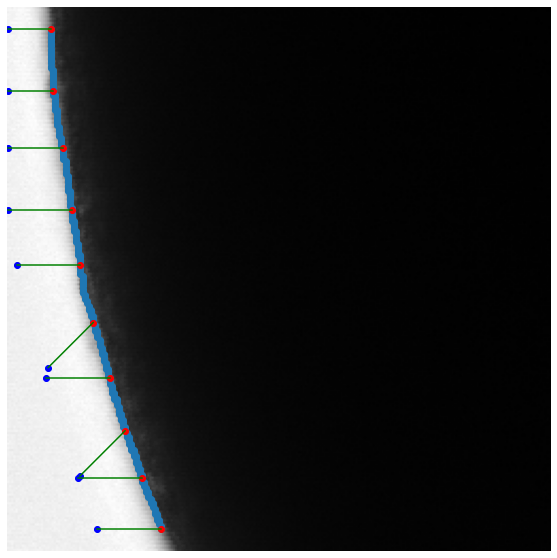

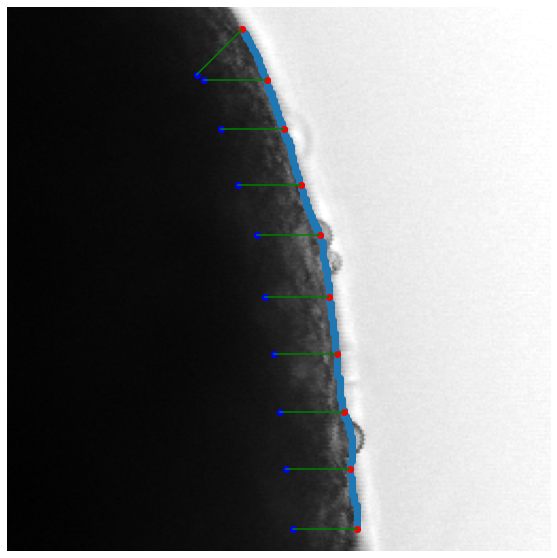

In [7]:
for i in range(1,3): #len(files)):
    example_file = files[i]

    print('Opening file:' , example_file)
    vid = tifffile.imread(os.path.join(filepath, example_file))
    print('Number of frames in video: ', vid.shape[0])
    border_points, track_points, static_points = get_tracking_points(vid[0])
    
    plt.figure(figsize=(10,10))
    plt.imshow(vid[0], cmap='gray')
    plt.axis('off')
    plt.scatter(border_points[1],border_points[0])
    plt.scatter(track_points[1], track_points[0], c='r')
    plt.scatter(static_points[1], static_points[0], c='b')
    for i in range(len(static_points[0])): 
        plt.plot((track_points[1][i], static_points[1][i]), (track_points[0][i], static_points[0][i]), c='g')


### Approach 2: Compute distance from one static point inside organoid

Opening file: 220516_No contraction videos.lif - O1445_2a.tif
Number of frames in video:  1208
Opening file: Weak contraction.lif - O1318_3a.tif
Number of frames in video:  796
Opening file: 220516_No contraction videos.lif - O1450_2 curare II.tif
Number of frames in video:  1208
Opening file: Strong contraction.lif - O1319_1a.tif
Number of frames in video:  1813
Opening file: Weak contraction.lif - O1318_2a.tif
Number of frames in video:  1813
Opening file: Strong contraction.lif - O1464_1a.tif
Number of frames in video:  1208
Opening file: Strong contraction.lif - O1468_1b.tif
Number of frames in video:  1208
Opening file: Strong contraction.lif - O1466_2a.tif
Number of frames in video:  1208
Opening file: Weak contraction.lif - O1443_1b.tif
Number of frames in video:  1509
Opening file: 220516_No contraction videos.lif - O1319_3a.tif
Number of frames in video:  1813
Opening file: Strong contraction.lif - O1464_2a.tif
Number of frames in video:  1208
Opening file: Weak contraction.li

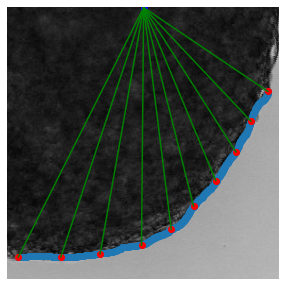

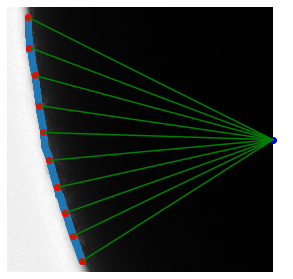

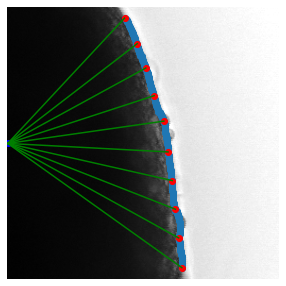

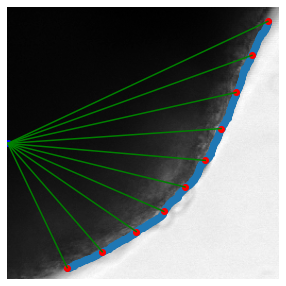

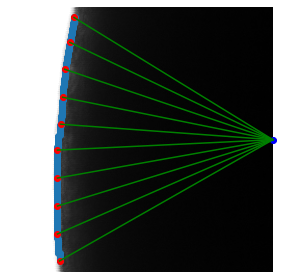

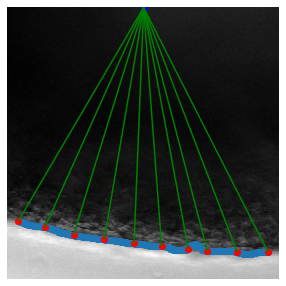

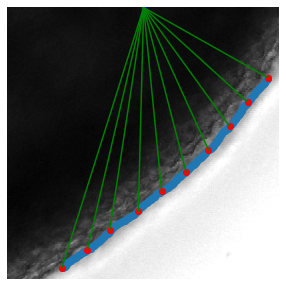

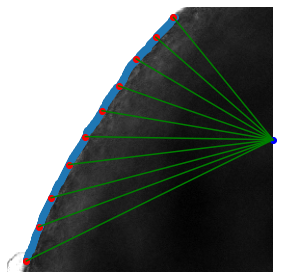

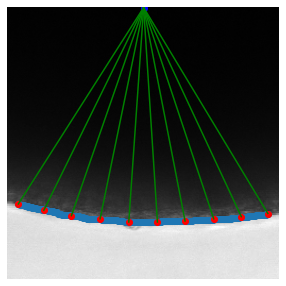

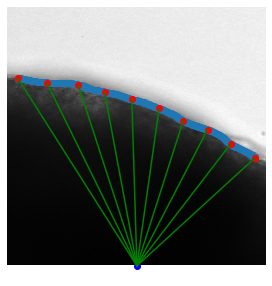

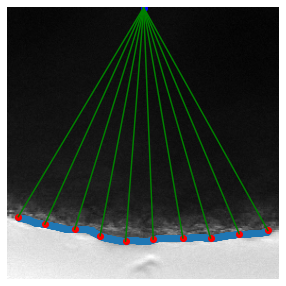

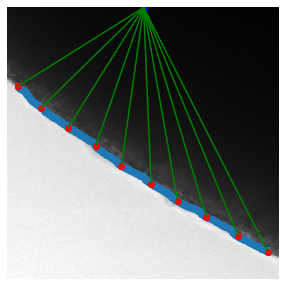

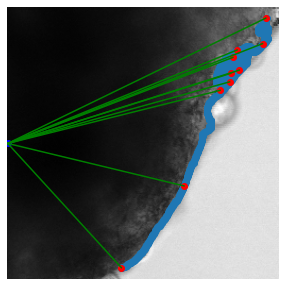

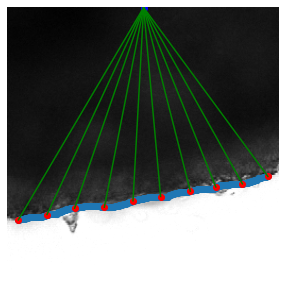

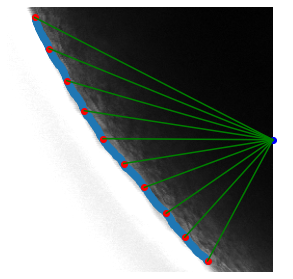

In [10]:
for i in range(len(files)):
    example_file = files[i]

    print('Opening file:' , example_file)
    vid = tifffile.imread(os.path.join(filepath, example_file))
    print('Number of frames in video: ', vid.shape[0])
    border_points, track_points, static_point = get_tracking_points(vid[0])

    plt.figure(figsize=(5,5))
    plt.imshow(vid[0], cmap='gray')
    plt.axis('off')
    plt.scatter(border_points[1],border_points[0])
    plt.scatter(track_points[1], track_points[0], c='r')
    plt.scatter(static_point[1], static_point[0], c='b')
    for i in range(len(static_points[0])): 
        plt.plot((track_points[1][i], static_point[1]), (track_points[0][i], static_point[0]), c='g')
    


### Step 2: Track points and compute distance from static points

In [83]:
# uncomment to save output video with result
# out = cv2.VideoWriter('outputww.mp4',cv2.VideoWriter_fourcc('m', 'p', '4', 'v'), 100, (256,256))

for i in range(11,len(files)): # add here to repeat for all videos
    filename = files[i]
    cv2.destroyAllWindows()
    print('Opening file:' , filename)
    vid = tifffile.imread(os.path.join(filepath, filename))
    _, track_points, static_points = get_tracking_points(vid[0])
    # add out as parameter if you wish to save video
    final_tracked_points_vid, points_lost, _ = track_points_in_vid(filename, vid, track_points, static_points, lose_points=True, view=True, wait=1, subsample=15) # view video and set frame rate
    #print('Done! Points lost during tracking: ', points_lost)
    
# out.release()

Opening file: Weak contraction.lif - O1318_1b.tif
kkkkkkkkk (10, 1, 2)
kkkkkkkkk (6, 1, 2)
kkkkkkkkk (6, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk (5, 1, 2)
kkkkkkkkk

In [85]:
final_tracked_points_vid

array([[66824.        , 66853.8671875 , 66880.7578125 , ...,
            0.        ,     0.        ,     0.        ],
       [54400.        , 54386.02734375, 54405.15625   , ...,
            0.        ,     0.        ,     0.        ],
       [42850.        , 42841.34375   , 42860.2890625 , ...,
            0.        ,     0.        ,     0.        ],
       ...,
       [15588.        , 15566.20214844, 15601.56542969, ...,
            0.        ,     0.        ,     0.        ],
       [16081.        , 16078.02539062, 16076.52148438, ...,
            0.        ,     0.        ,     0.        ],
       [17658.        , 17611.02734375, 17650.70898438, ...,
            0.        ,     0.        ,     0.        ]])

### Step 3: Extract signals

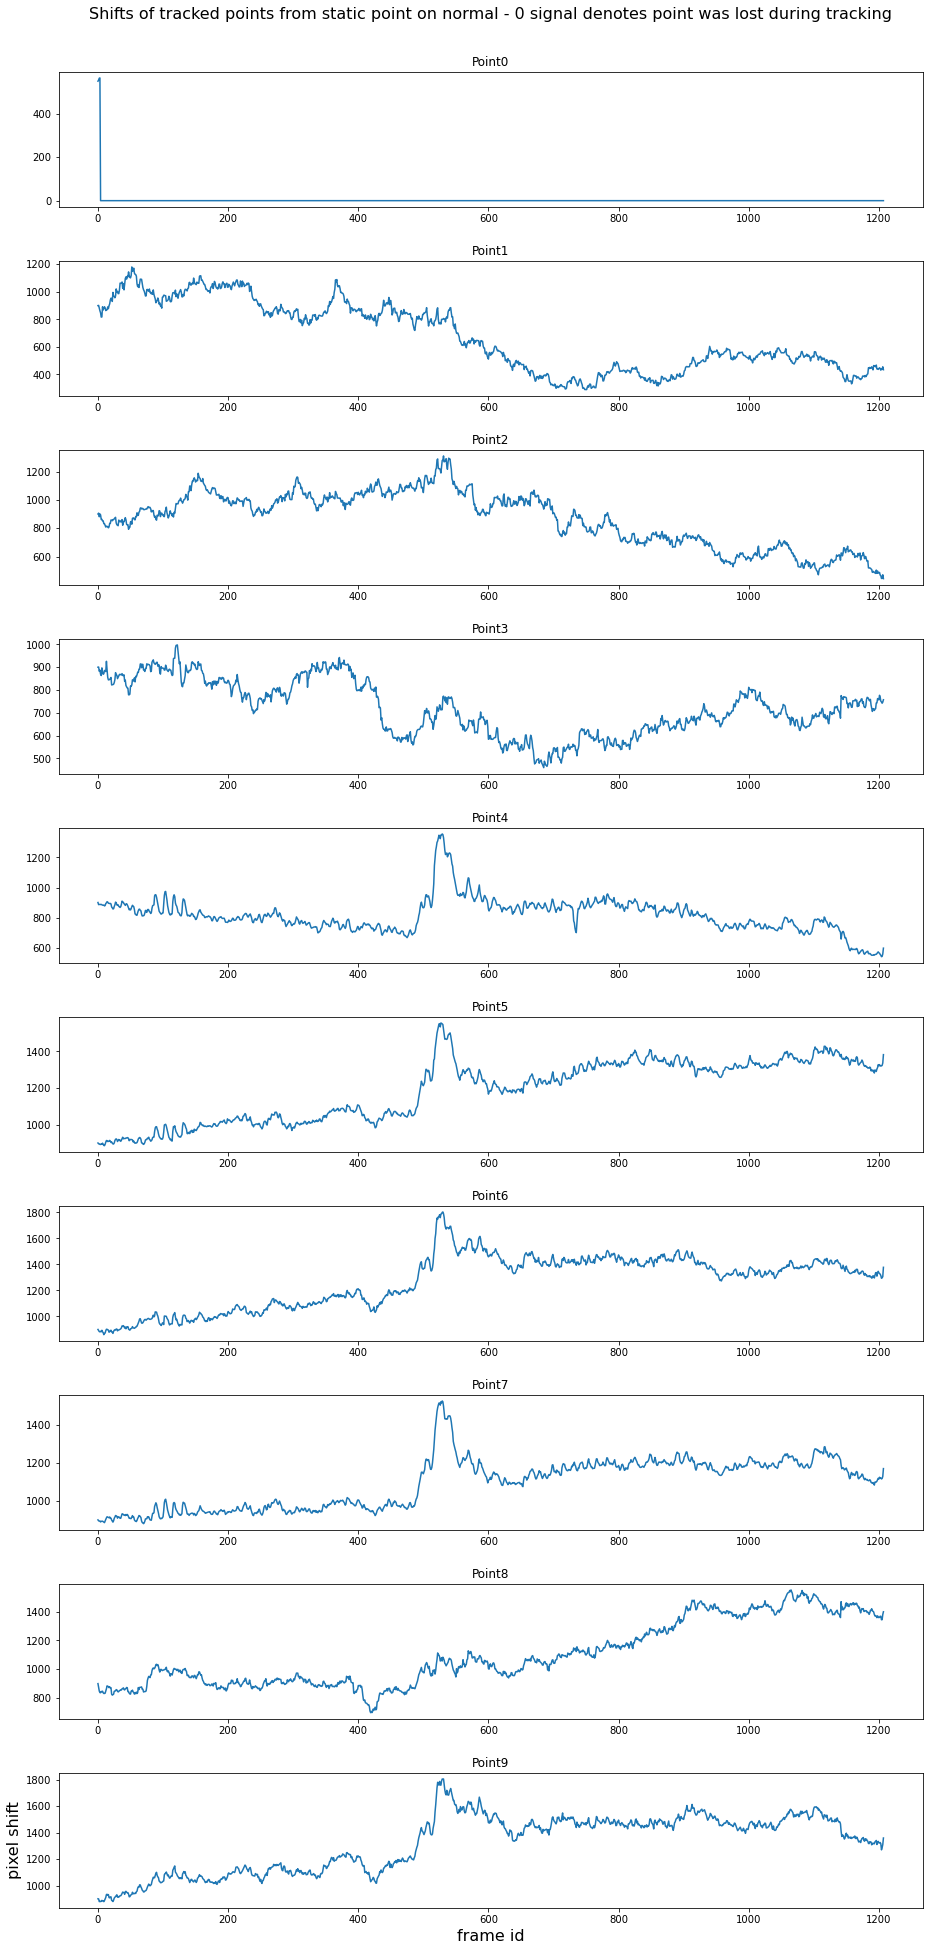

In [64]:
fig, ax = plt.subplots(10, figsize=(15,30))
fig.suptitle('Shifts of tracked points from static point on normal - 0 signal denotes point was lost during tracking', fontsize=16)
for i in range(10):
    ax[i].plot(np.arange(distances.shape[1]), distances[i,:])
    ax[i].set_title('Point'+str(i))
plt.xlabel('frame id', fontsize=16)
plt.ylabel('pixel shift', fontsize=16)
plt.subplots_adjust(left=0.1,
                    bottom=0.1, 
                    right=0.9, 
                    top=0.95, 
                    wspace=0.4, 
                    hspace=0.4)

### Save distance plots as numpy arrays

In [67]:
new_file = example_file.split('.')[0]+'.npy'
print('Shape of extracted signal: ', distances.shape)
np.save(new_file, distances)

# Extract signals for all videos

In [ ]:
for file in files:
    print('Opening file:' , example_file)
    vid = tifffile.imread(os.path.join(filepath, file))
    border_points, track_points, static_points = get_tracking_points(vid[0])
    distances, points_lost = track_points_in_vid(vid, track_points, static_points, view=True, wait=20) # view video and set frame rate
    new_file = file.split('.')[0]+'.npy'
    np.save(new_file, distances)